In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


In [2]:
from pathlib import Path
import pandas as pd

path = Path('../../data/Airbnb Prices in European Cities/raw')

files = {
    "london_weekdays": "london_weekdays.csv",
    "london_weekends": "london_weekends.csv"
}

dfs = {}

for key, file_name in files.items():
    file_path = path / file_name
    dfs[key] = pd.read_csv(file_path)
    print(f"Lido: {file_name}")

df_weekdays = dfs["london_weekdays"]
df_weekends = dfs["london_weekends"]


Lido: london_weekdays.csv
Lido: london_weekends.csv


In [3]:
df_weekdays["dataset"] = "weekday"
df_weekends["dataset"] = "weekend"

df_all = pd.concat([df_weekdays, df_weekends], ignore_index=True)


In [4]:
print("\n=== INFO WEEKDAYS ===")
df_weekdays.info()

print("\n=== INFO WEEKENDS ===")
df_weekends.info()

print("\n=== Missing Values Comparison ===")
print(pd.DataFrame({
    "weekdays": df_weekdays.isna().sum(),
    "weekends": df_weekends.isna().sum()
}))



=== INFO WEEKDAYS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4614 entries, 0 to 4613
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  4614 non-null   int64  
 1   realSum                     4614 non-null   float64
 2   room_type                   4614 non-null   object 
 3   room_shared                 4614 non-null   bool   
 4   room_private                4614 non-null   bool   
 5   person_capacity             4614 non-null   float64
 6   host_is_superhost           4614 non-null   bool   
 7   multi                       4614 non-null   int64  
 8   biz                         4614 non-null   int64  
 9   cleanliness_rating          4614 non-null   float64
 10  guest_satisfaction_overall  4614 non-null   float64
 11  bedrooms                    4614 non-null   int64  
 12  dist                        4614 non-null   float64
 13  metro_dist

In [5]:
numeric_cols = df_all.select_dtypes(include=np.number).columns

stats_compare = pd.concat([
    df_weekdays[numeric_cols].describe().add_prefix("wd_"),
    df_weekends[numeric_cols].describe().add_prefix("we_")
], axis=1)

stats_compare


,wd_Unnamed: 0,wd_realSum,wd_person_capacity,wd_multi,wd_biz,wd_cleanliness_rating,wd_guest_satisfaction_overall,wd_bedrooms,wd_dist,wd_metro_dist,wd_attr_index,wd_attr_index_norm,wd_rest_index,wd_rest_index_norm,wd_lng,wd_lat,we_Unnamed: 0,we_realSum,we_person_capacity,we_multi,we_biz,we_cleanliness_rating,we_guest_satisfaction_overall,we_bedrooms,we_dist,we_metro_dist,we_attr_index,we_attr_index_norm,we_rest_index,we_rest_index_norm,we_lng,we_lat
count,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,4614.000000,5379.00000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000,5379.000000
mean,2306.500000,360.230348,2.832466,0.269397,0.422844,9.153013,90.324447,1.123754,5.325023,0.992739,296.466825,20.607738,629.790258,11.276920,-0.114886,51.503262,2689.00000,364.389747,2.857966,0.279792,0.357873,9.193902,90.921175,1.133110,5.327620,1.016534,294.575060,20.477061,625.612765,11.197378,-0.114782,51.503457
std,1332.091401,507.782888,1.240572,0.443695,0.494065,1.183012,11.755838,0.581591,2.720524,1.262465,172.440566,11.986535,389.953206,6.982438,0.068183,0.031465,1552.92788,437.742534,1.251068,0.448939,0.479419,1.151321,11.289857,0.577676,2.705986,1.265193,170.516734,11.853283,388.206414,6.948218,0.067520,0.031966
min,0.000000,64.676968,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.040553,0.013904,68.740487,4.778228,140.521726,2.516159,-0.251700,51.416510,0.00000,54.328653,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.040561,0.013875,68.740518,4.778421,140.521722,2.515094,-0.251700,51.414400
25%,1153.250000,167.454550,2.000000,0.000000,0.000000,9.000000,86.000000,1.000000,3.553956,0.317995,178.041401,12.375855,386.186620,6.914994,-0.171242,51.486300,1344.50000,174.510219,2.000000,0.000000,0.000000,9.000000,87.000000,1.000000,3.545684,0.324035,177.224481,12.319565,382.129695,6.839456,-0.169960,51.485690
50%,2306.500000,256.355982,2.000000,0.000000,0.000000,9.000000,93.000000,1.000000,4.899843,0.523462,251.181941,17.459935,530.331957,9.496036,-0.118225,51.509800,2689.00000,268.115431,2.000000,0.000000,0.000000,10.000000,94.000000,1.000000,4.939138,0.536131,247.646069,17.214844,527.347208,9.438596,-0.118130,51.509640
75%,3459.750000,435.452386,4.000000,1.000000,1.000000,10.000000,99.000000,1.000000,6.835232,1.047957,361.797354,25.148936,775.523995,13.886404,-0.067260,51.524698,4033.50000,438.274654,4.000000,1.000000,1.000000,10.000000,99.000000,1.000000,6.838065,1.090765,361.070549,25.099422,764.221221,13.678228,-0.067725,51.525720
max,4613.000000,15499.894165,6.000000,1.000000,1.000000,10.000000,100.000000,8.000000,17.321206,9.286229,1438.618956,100.000000,5584.771840,100.000000,0.120180,51.575820,5378.00000,12937.275101,6.000000,1.000000,1.000000,10.000000,100.000000,8.000000,17.321199,9.174094,1438.561236,100.000000,5587.136047,100.000000,0.120180,51.575820


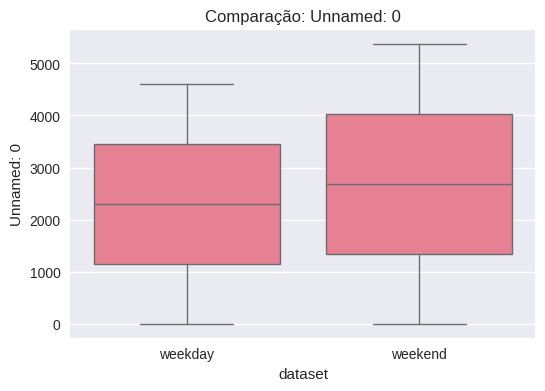

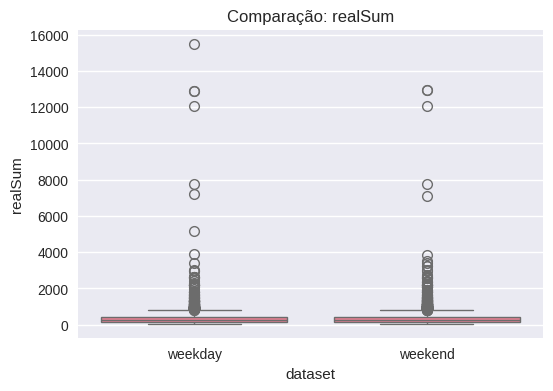

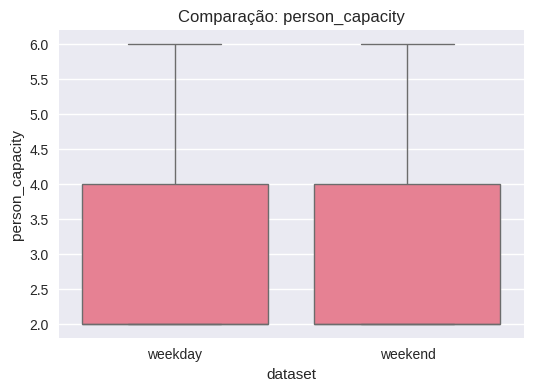

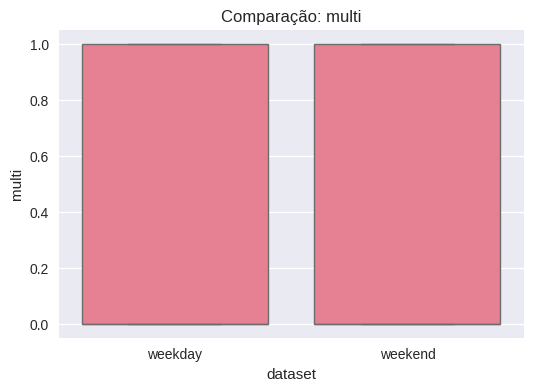

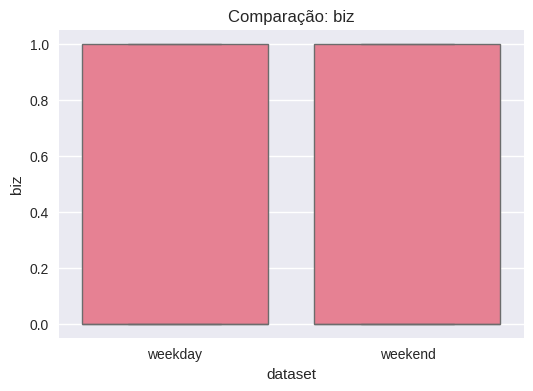

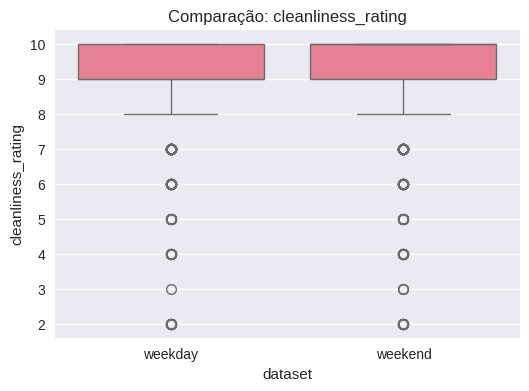

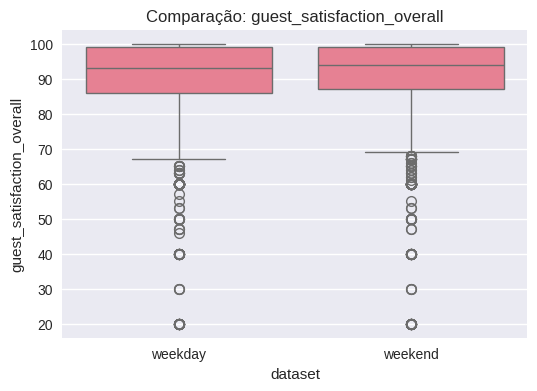

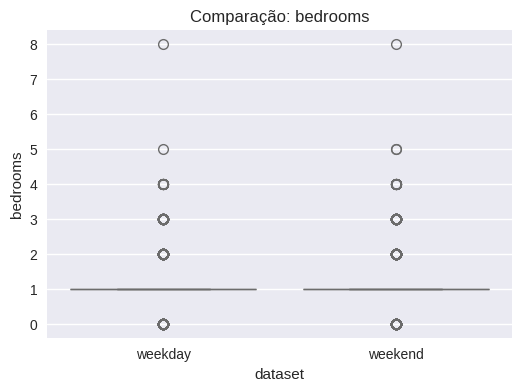

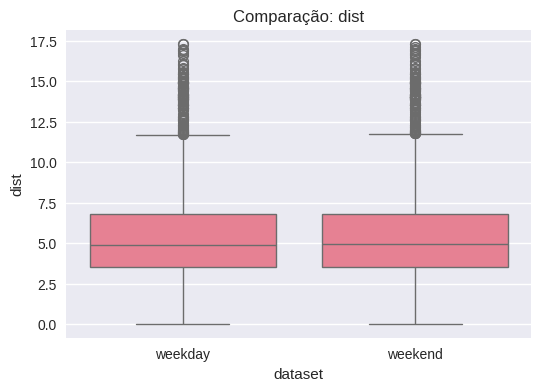

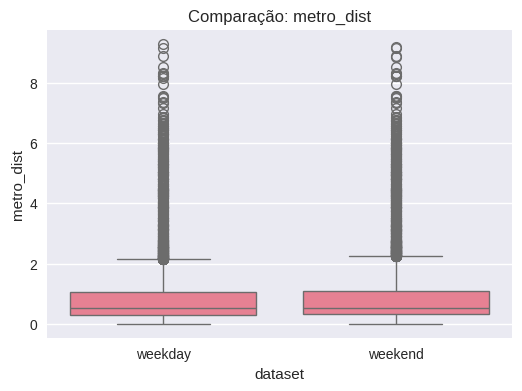

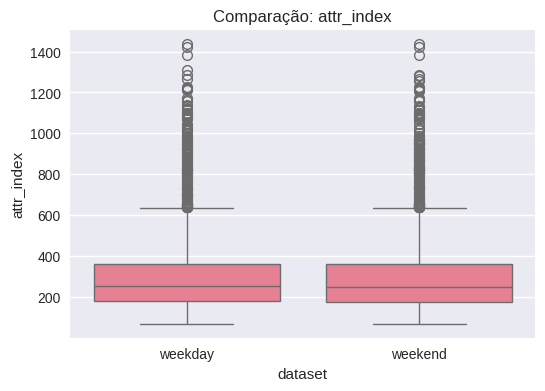

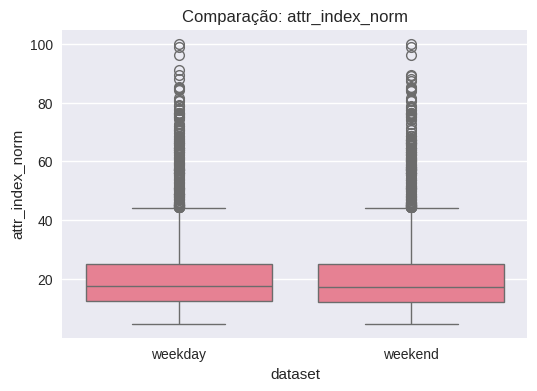

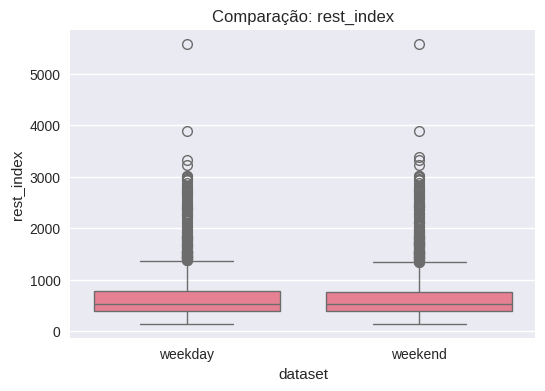

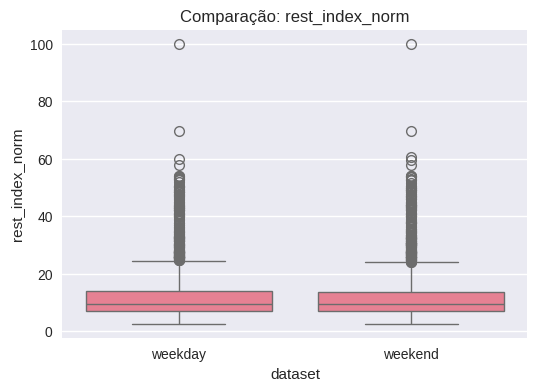

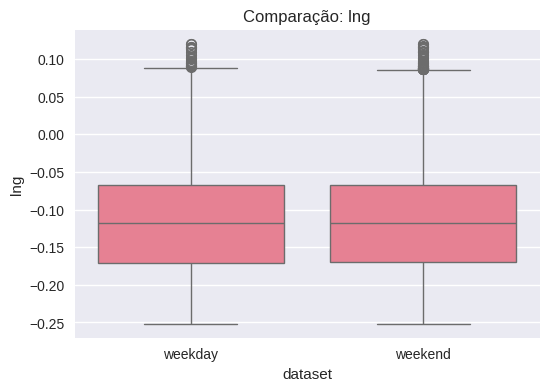

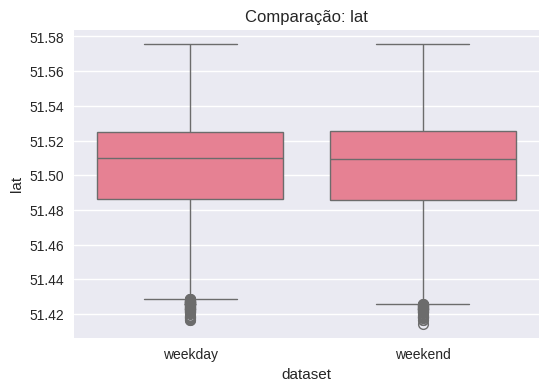

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_all, x="dataset", y=col)
    plt.title(f"Comparação: {col}")
    plt.show()


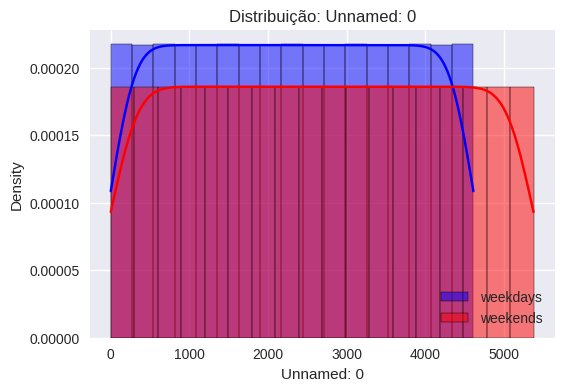

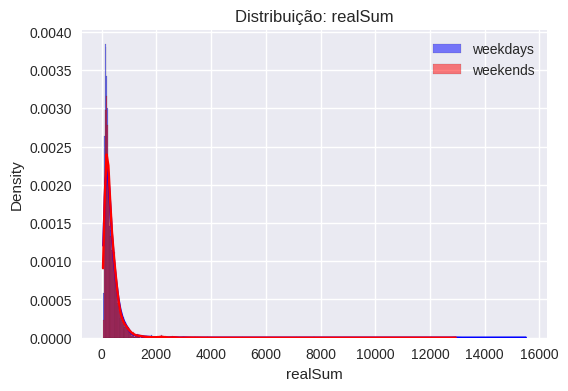

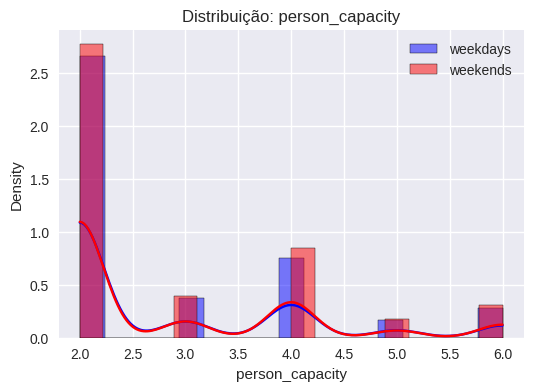

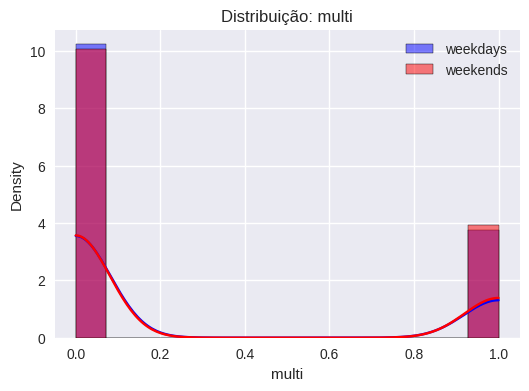

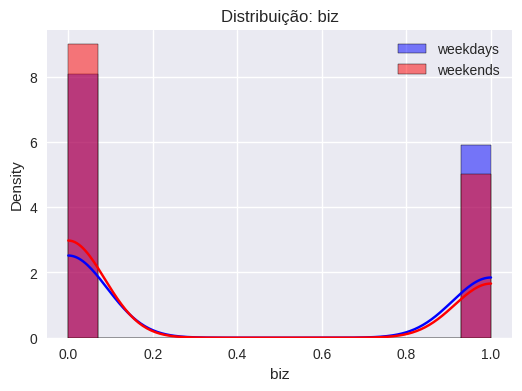

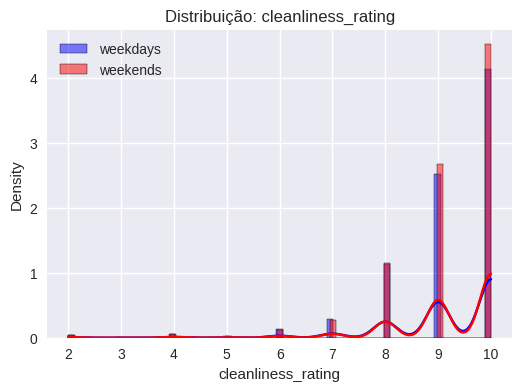

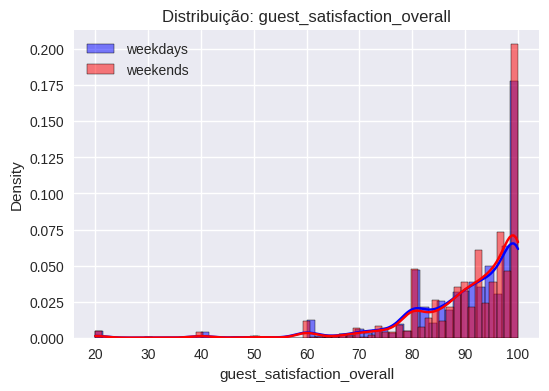

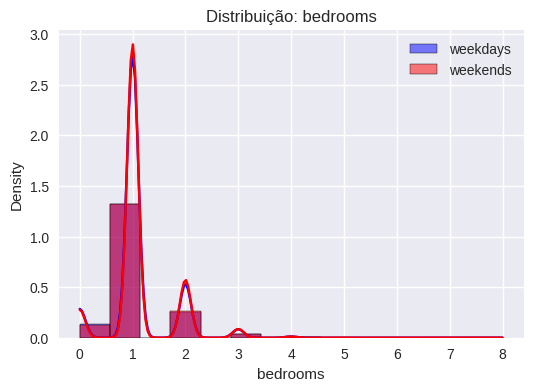

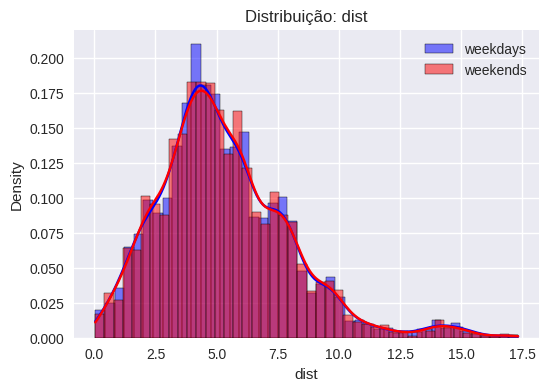

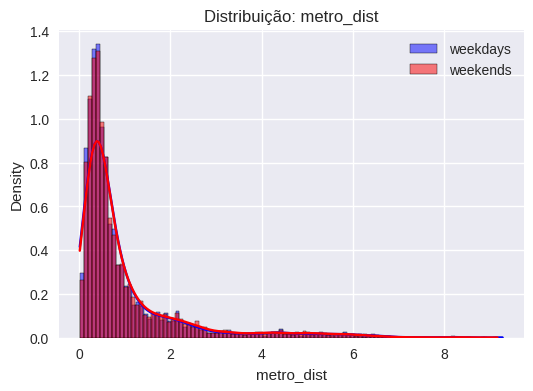

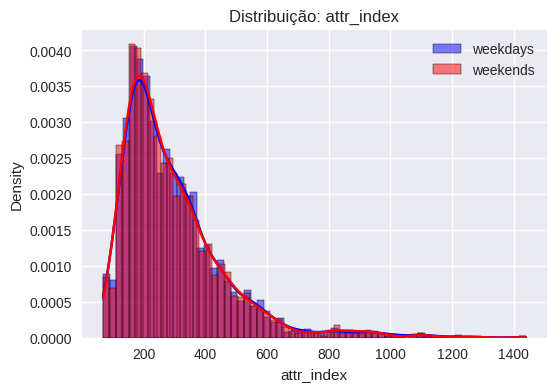

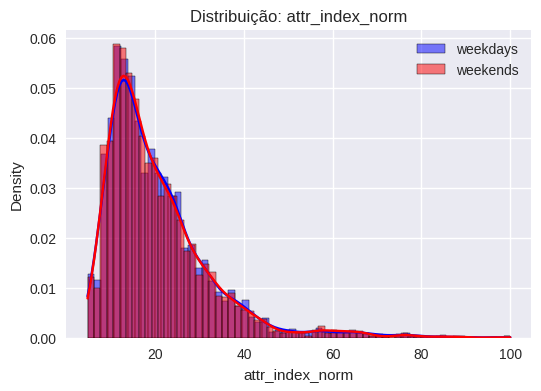

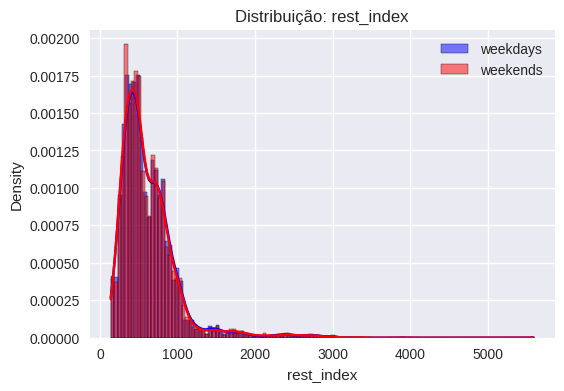

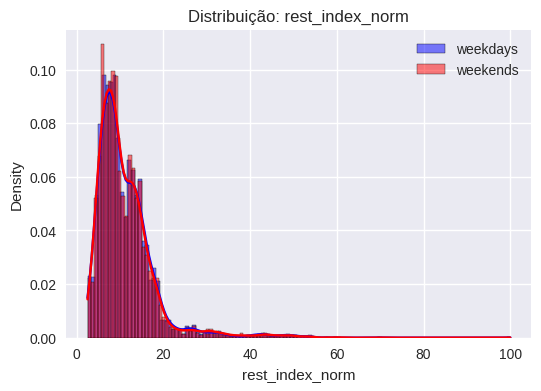

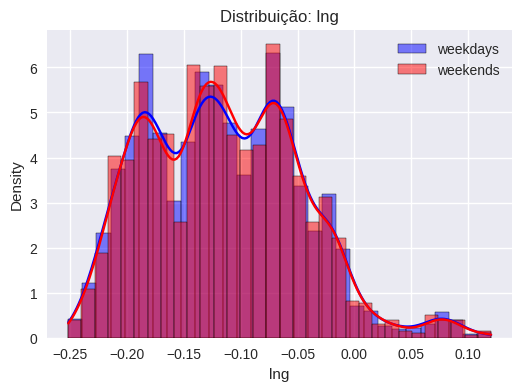

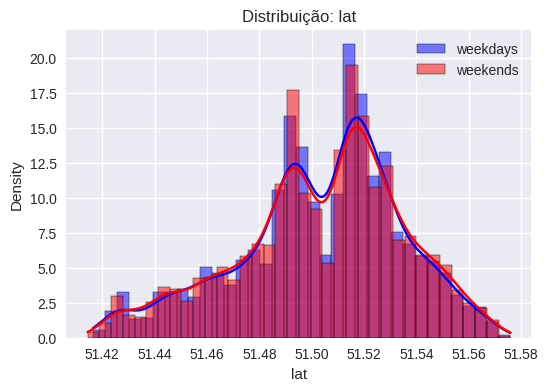

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_weekdays[col], kde=True, color="blue", label="weekdays", stat="density")
    sns.histplot(df_weekends[col], kde=True, color="red", label="weekends", stat="density")
    plt.legend()
    plt.title(f"Distribuição: {col}")
    plt.show()


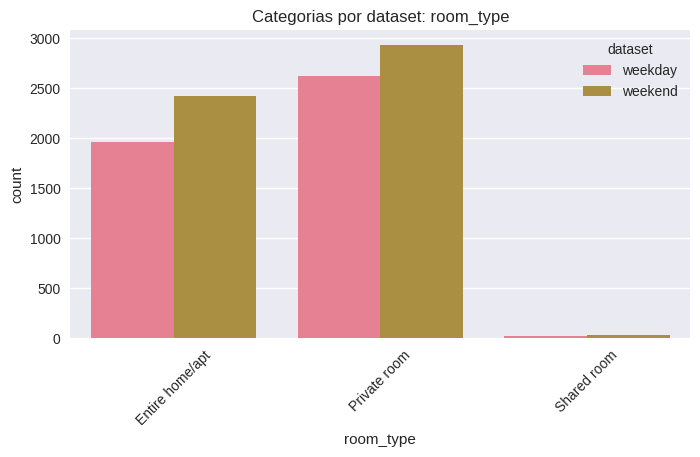

In [8]:
categorical_cols = df_all.select_dtypes(include=["object"]).columns
categorical_cols = [c for c in categorical_cols if c != "dataset"]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df_all, x=col, hue="dataset")
    plt.xticks(rotation=45)
    plt.title(f"Categorias por dataset: {col}")
    plt.show()


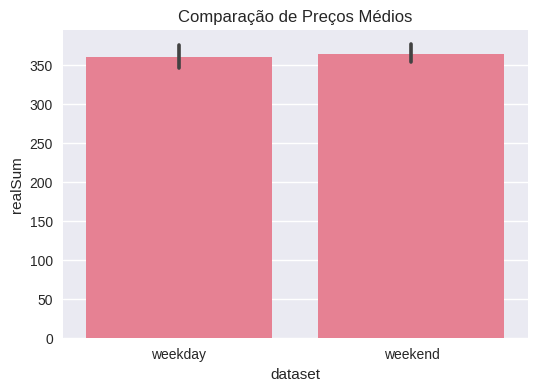

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df_all,
    x="dataset",
    y="realSum"
)
plt.title("Comparação de Preços Médios")
plt.show()


Avaliação RealSum

In [10]:
# ============================
# 1. Estatísticas Descritivas
# ============================

print("\n=== Estatísticas — realSum ===")
display(df_all.groupby("dataset")["realSum"].describe())


=== Estatísticas — realSum ===


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
weekday,4614.0,360.230348,507.782888,64.676968,167.454550,256.355982,435.452386,15499.894165
weekend,5379.0,364.389747,437.742534,54.328653,174.510219,268.115431,438.274654,12937.275101


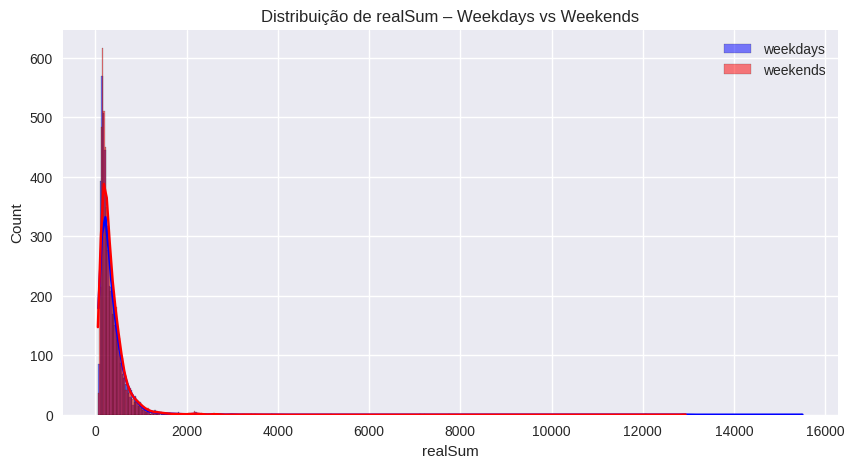

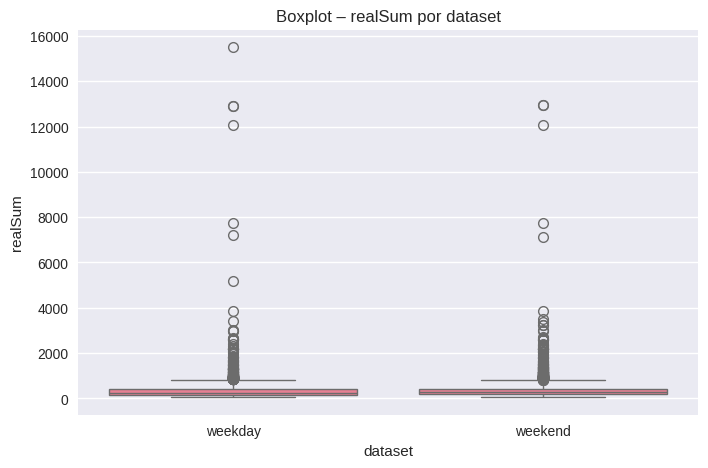

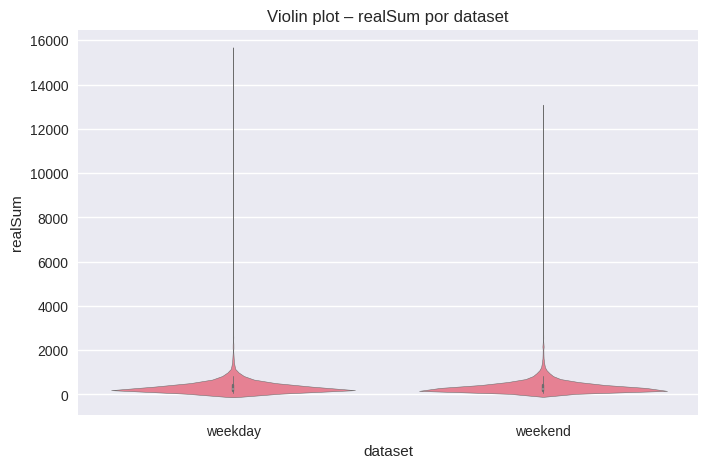

In [11]:
# ============================
# 2. Comparação de Distribuições
# ============================

plt.figure(figsize=(10,5))
sns.histplot(df_weekdays["realSum"], kde=True, color="blue", alpha=0.5, label="weekdays")
sns.histplot(df_weekends["realSum"], kde=True, color="red", alpha=0.5, label="weekends")
plt.title("Distribuição de realSum – Weekdays vs Weekends")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_all, x="dataset", y="realSum")
plt.title("Boxplot – realSum por dataset")
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(data=df_all, x="dataset", y="realSum")
plt.title("Violin plot – realSum por dataset")
plt.show()


In [12]:


# ============================
# 3. Testes Estatísticos
# ============================
w1 = df_weekdays["realSum"]
w2 = df_weekends["realSum"]

print("\n=== Testes Estatísticos de realSum ===")
print("T-test p-value:", ttest_ind(w1, w2, equal_var=False).pvalue)
print("Mann-Whitney p-value:", mannwhitneyu(w1, w2).pvalue)
print("KS test p-value:", ks_2samp(w1, w2).pvalue)


=== Testes Estatísticos de realSum ===
T-test p-value: 0.6637065371498843
Mann-Whitney p-value: 0.004946780541187525
KS test p-value: 0.002473590297620931


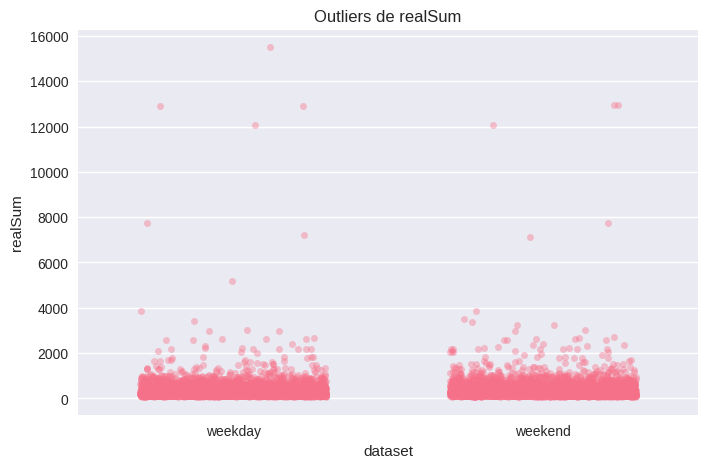

In [13]:
# ============================
# 4. Outliers
# ============================

plt.figure(figsize=(8,5))
sns.stripplot(data=df_all, x="dataset", y="realSum", alpha=0.4, jitter=0.3)
plt.title("Outliers de realSum")
plt.show()

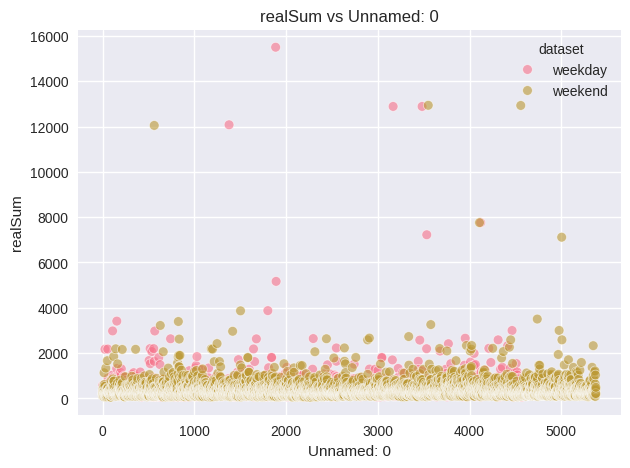

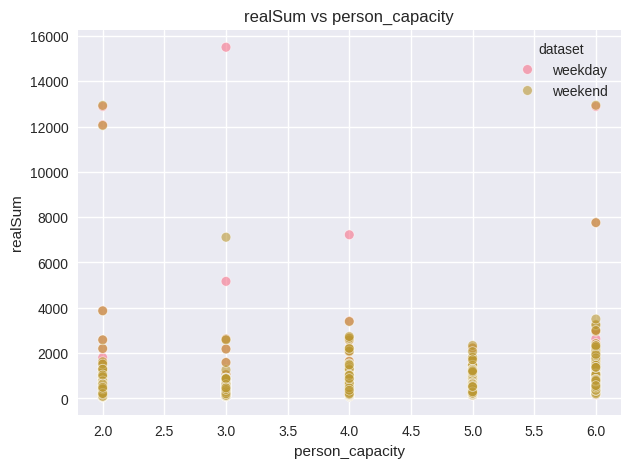

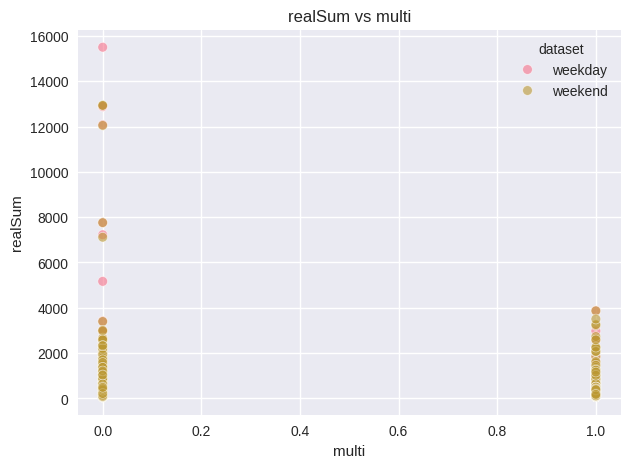

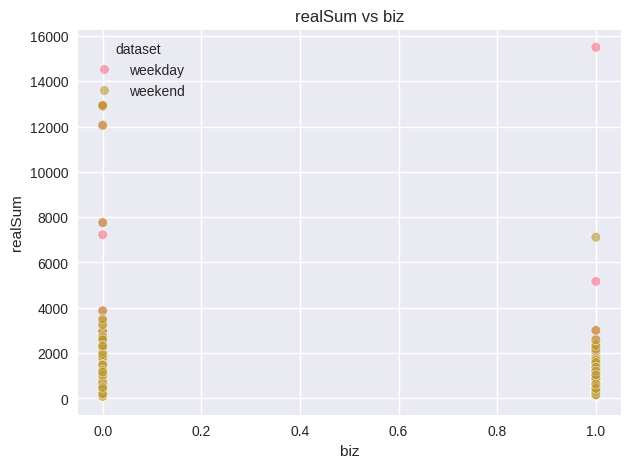

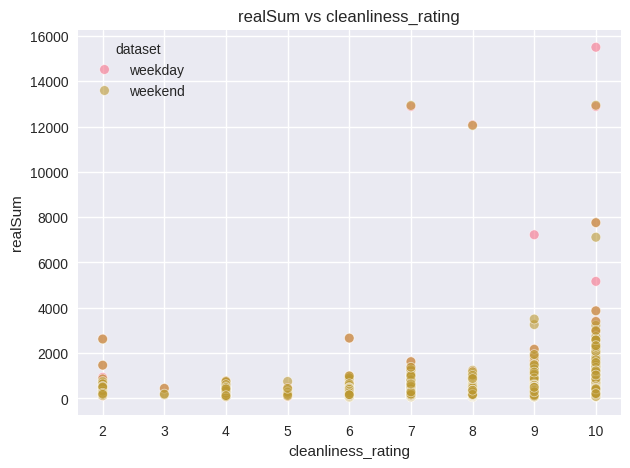

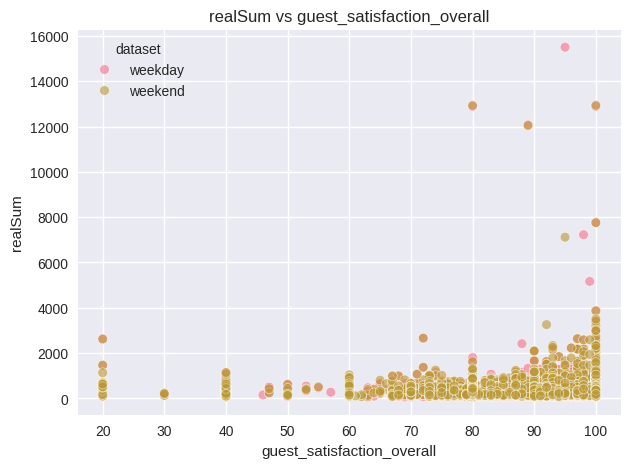

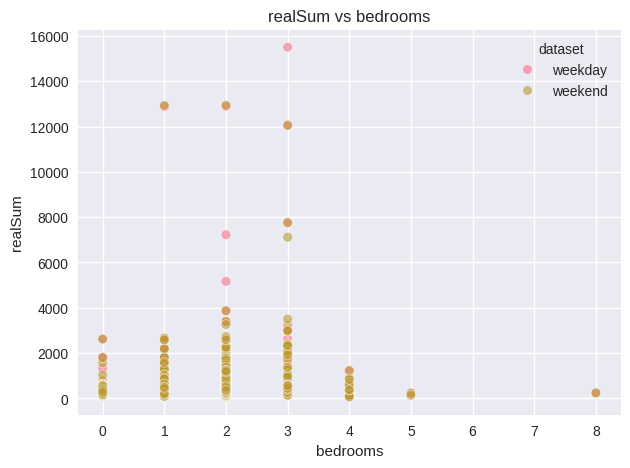

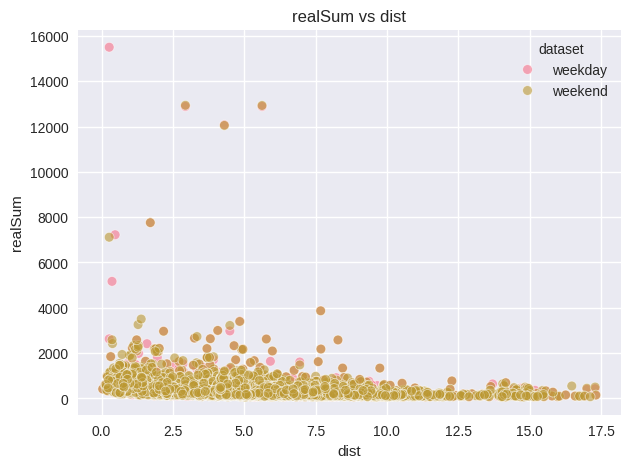

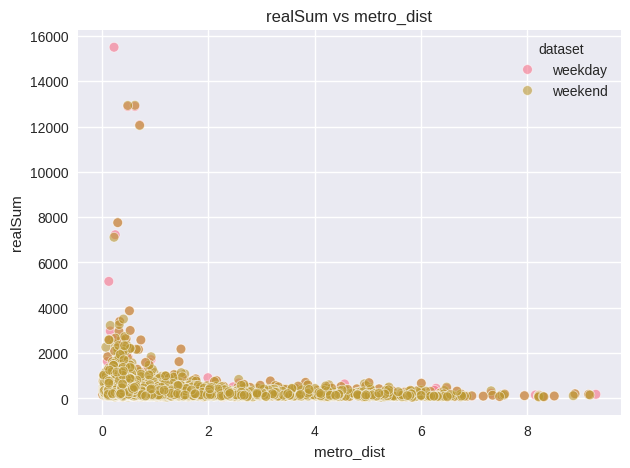

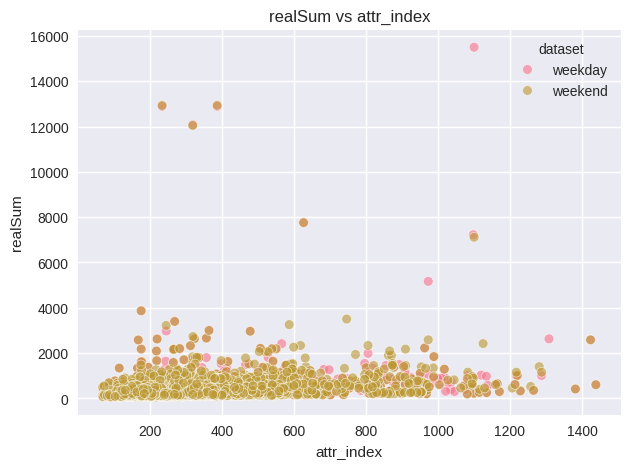

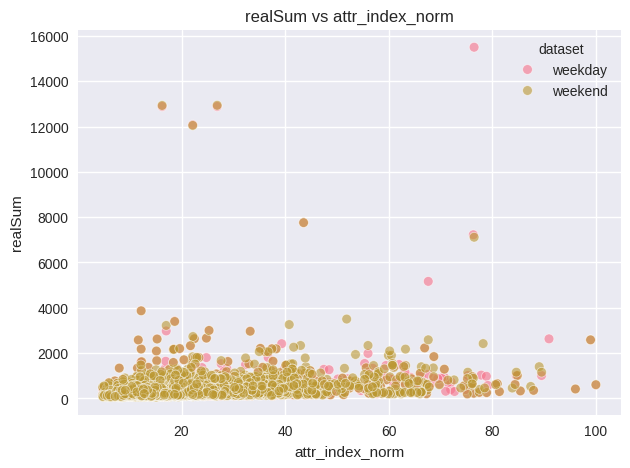

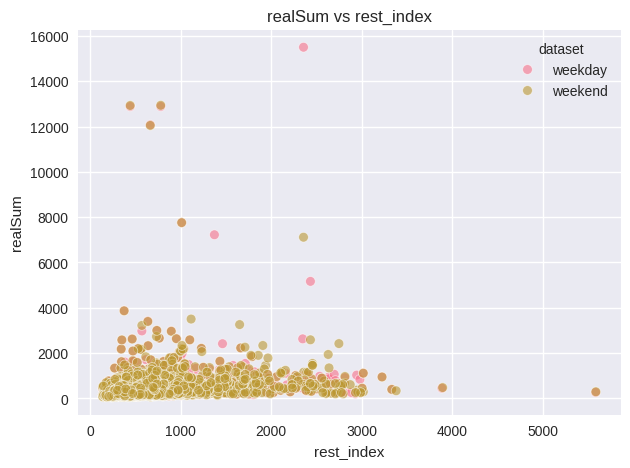

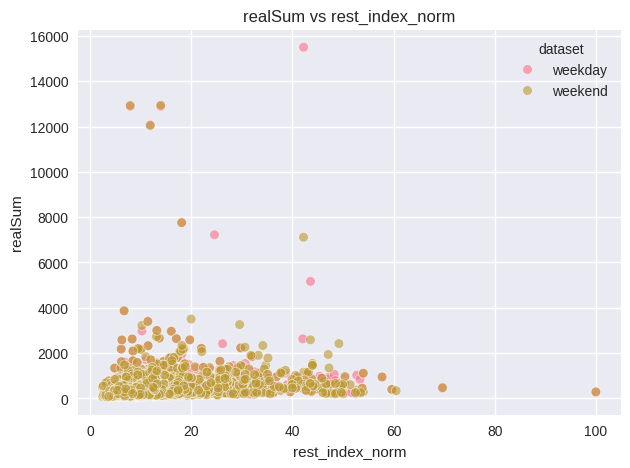

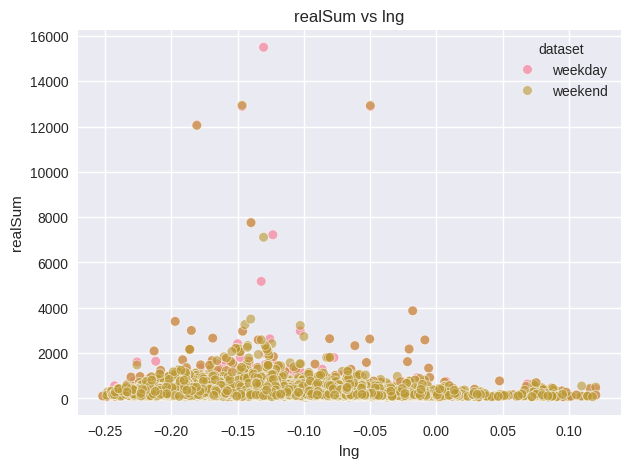

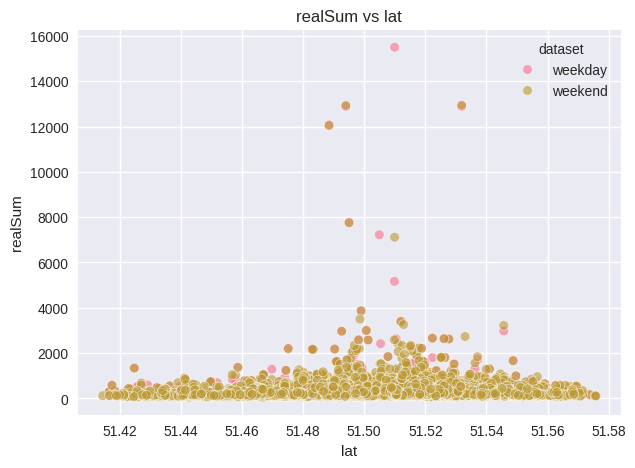

In [14]:
# ============================
# 5. Relação com Numéricas
# ============================

for col in numeric_cols:
    if col == "realSum":
        continue
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_all, x=col, y="realSum", hue="dataset", alpha=0.6)
    plt.title(f"realSum vs {col}")
    plt.show()


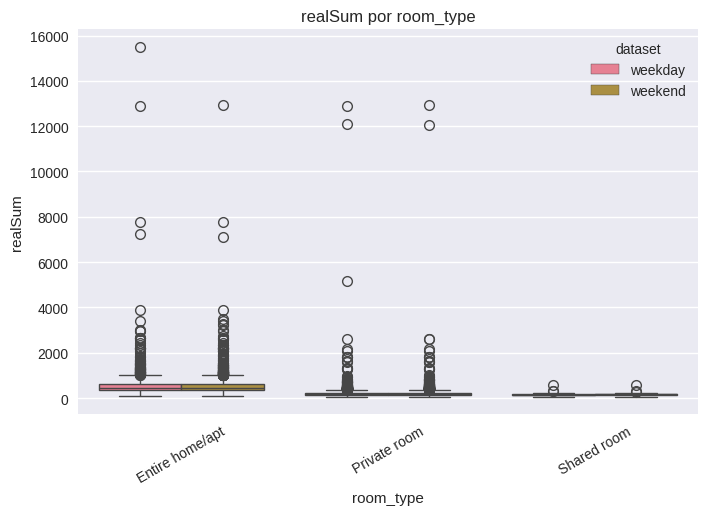

In [15]:

# ============================
# 6. Relação com Categóricas
# ============================

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_all, x=col, y="realSum", hue="dataset")
    plt.title(f"realSum por {col}")
    plt.xticks(rotation=30)
    plt.show()

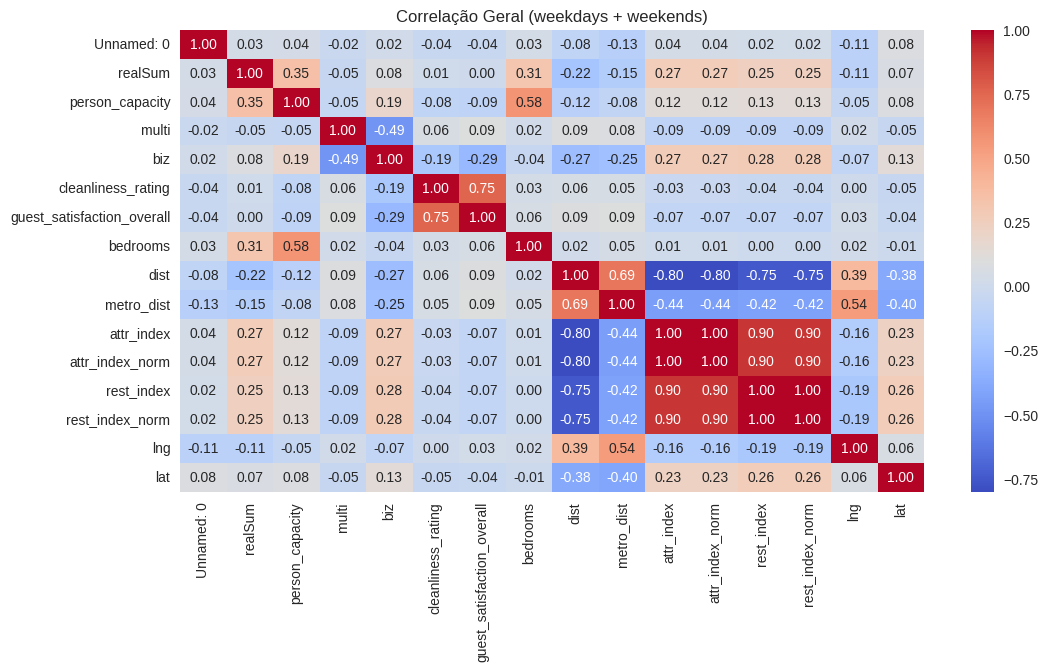

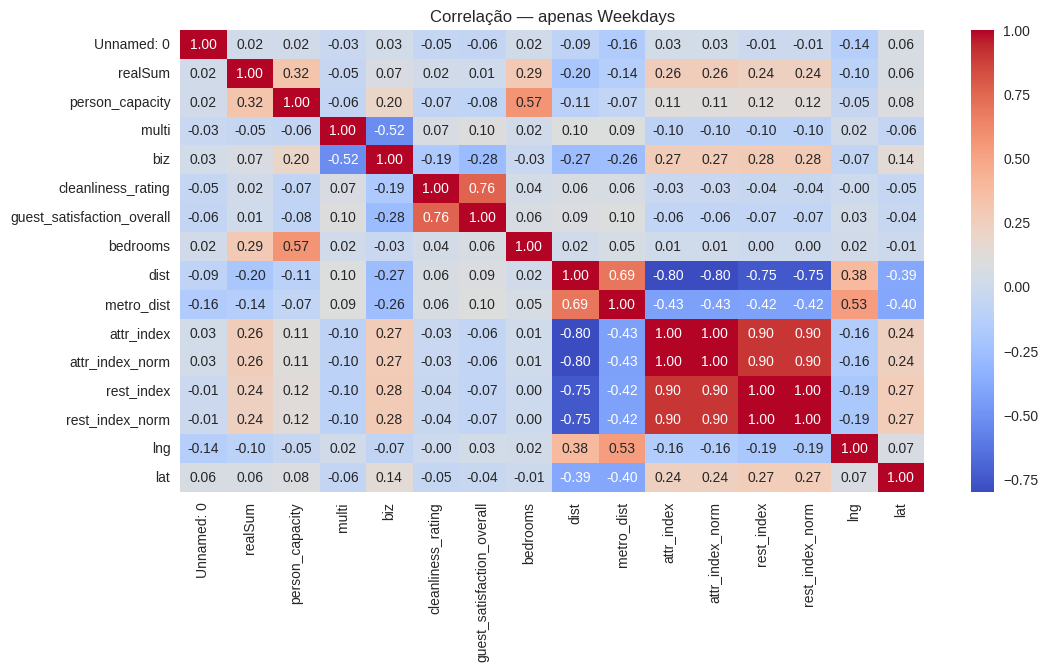

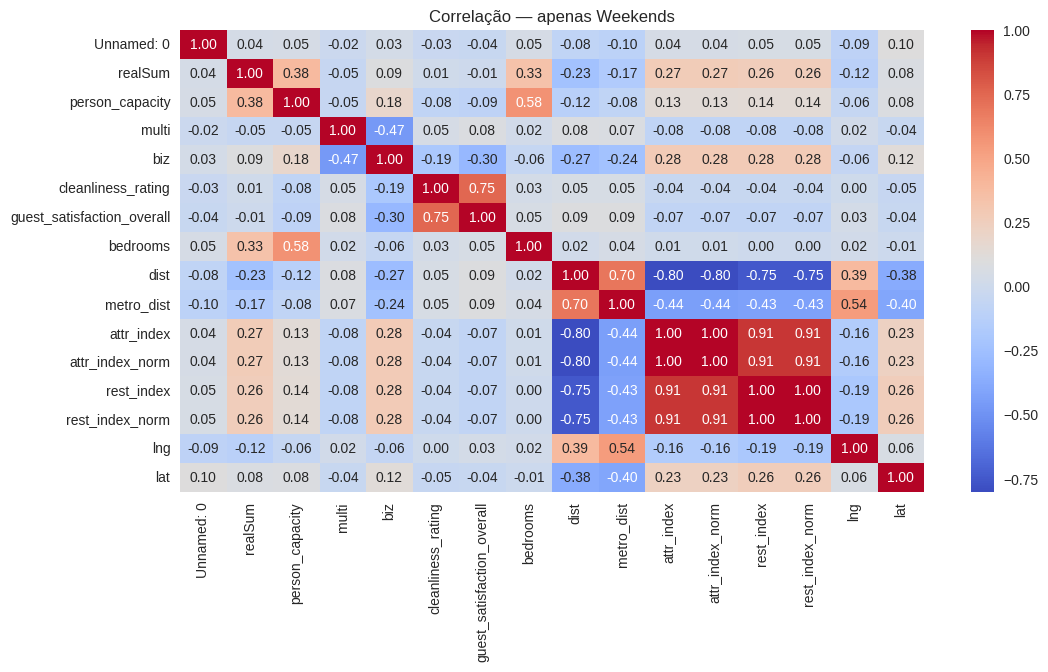

In [16]:
# ============================
# 7. Correlações Numéricas
# ============================

plt.figure(figsize=(12,6))
sns.heatmap(df_all[numeric_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação Geral (weekdays + weekends)")
plt.show()

# Correlações separadas
plt.figure(figsize=(12,6))
sns.heatmap(df_weekdays[numeric_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação — apenas Weekdays")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(df_weekends[numeric_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação — apenas Weekends")
plt.show()

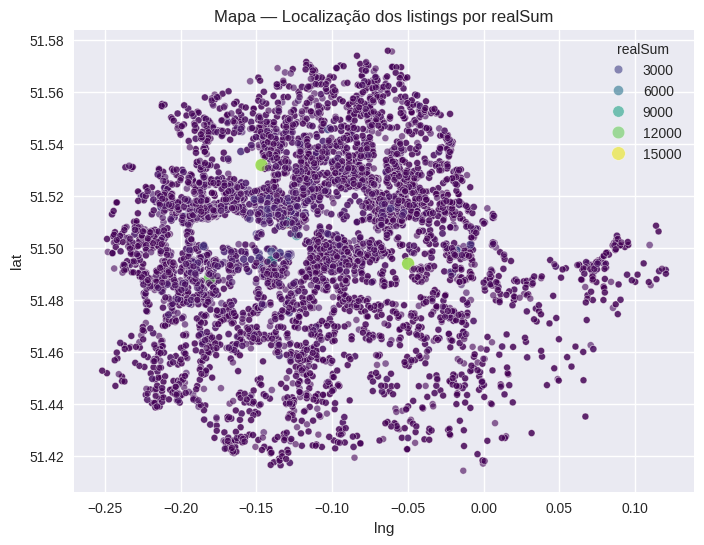

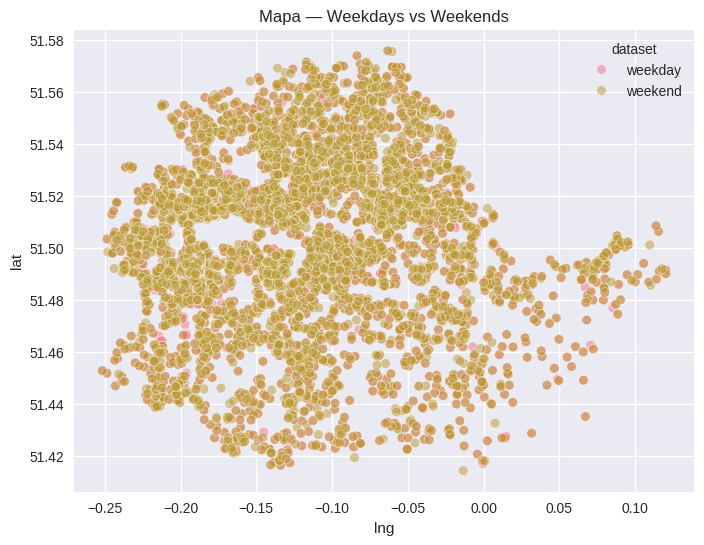

In [17]:
# ============================
# 8. Análise Espacial
# ============================

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_all, x="lng", y="lat", hue="realSum", size="realSum",
                alpha=0.6, palette="viridis")
plt.title("Mapa — Localização dos listings por realSum")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_all, x="lng", y="lat", hue="dataset", alpha=0.5)
plt.title("Mapa — Weekdays vs Weekends")
plt.show()